# Cyber Trend Forecasting - VisionTS Pipeline

**Vignette Description:**
This notebook acts as the Pipeline Dashboard for the VisionTS model. It handles the end-to-end workflow:
1.  **Setup:** Automatically detects if running on Google Colab or the NATO Local Server.
2.  **Training:** Executes `Train_Vision.py` to train/evaluate the VisionTS model.
3.  **Evaluation:** Runs `Evaluate_Vision.py` to generate metrics and predictions.
4.  **Visualisation:** Runs `Visualise_Vision_Results.py` and displays the Gap Analysis inline.

**Model Architecture:**
VisionTS converts time series to 2D image representations and leverages a pretrained Masked Autoencoder (MAE) for forecasting.

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [5]:
import os
import sys

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root
# e.g., /content/drive/MyDrive/NATO_Project_Root

try:
    # 1. CHECK ENVIRONMENT: Try to import Colab-specific modules
    import google.colab
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

# 2. PATH SETUP
if IS_COLAB:
    # --- COLAB SETUP ---
    try:
        drive.mount('/content/drive')

        # Get the PARENT ROOT from Secrets
        PROJECT_ROOT = userdata.get('project_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")

    except Exception as e:
        print(f"CRITICAL COLAB SETUP ERROR: {e}")
        # Stop execution if we can't find the files
        raise e
else:
    # --- LOCAL SETUP ---
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    # os.getcwd() returns /.../Project_Root/Notebooks
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 3. CONFIGURE WORKING DIRECTORY
# We need to run scripts from inside 'Transformer_Pipeline'
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'Transformer_Pipeline')

if not os.path.exists(PIPELINE_DIR):
    raise FileNotFoundError(f"Could not find pipeline folder at: {PIPELINE_DIR}")

# Change CWD to the pipeline folder so scripts can find config/data
os.chdir(PIPELINE_DIR)
print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

# 4. ADD PROJECT ROOT TO SYS.PATH
# This allows us to import 'Notebooks.colab_utils' if needed
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added Project Root to sys.path: {PROJECT_ROOT}")

# 5. INSTALL DEPENDENCIES (COLAB ONLY)
if IS_COLAB:
    print("\n--- Installing Dependencies (Colab Only) ---")
    # We import the helper script from the sibling folder
    try:
        from Notebooks import colab_utils
        colab_utils.setup_environment()
    except ImportError:
        print("WARNING: Could not import Notebooks.colab_utils. Skipping auto-install.")

--- Detected Environment: LOCAL SERVER (NATO/BBK) ---
SUCCESS: Working Directory set to: /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Transformer_Pipeline


## Step 1: Train VisionTS Model

We now execute the training script.
* **Input:** `Cyber_Trend_Vision_Config.py` (Hyperparameters)
* **Output:** `vision_best.pt` (Saved weights)

**Available modes:**
- `zero_shot`: Evaluate pretrained MAE without training (fastest)
- `train`: Fine-tune the model on cyber threat data

*Note: Zero-shot mode is recommended for initial testing. Training on T4 GPU should take ~5-10 minutes.*

In [6]:
print("--- Step 1: Training VisionTS Model ---")
# We use %run to execute the script in a fresh namespace.
# This runs the script as if it were in the terminal, showing live progress bars.
# This is cleaner for demo purposes than importing the main function.
%run Train_Vision.py --data_dir ../Processed_Data/vision --mode train

--- Step 1: Training VisionTS Model ---
Random seed: 123

--- Loading Preprocessed Data ---
Data directory: /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Transformer_Pipeline/../Processed_Data/vision
Initializing VisionTS dataset for split: train from /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Transformer_Pipeline/../Processed_Data/vision
Loading windowed data from /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Transformer_Pipeline/../Processed_Data/vision/train.npz...
Loaded 25 samples for train.
  X shape: (25, 10, 13) (samples, context_len, nvars)
  y shape: (25, 36, 13) (samples, pred_len, nvars)
Initializing VisionTS dataset for split: val from /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Transformer_Pipeline/../Processed_Data/vision
Loading windowed data from /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Transformer_Pipeline/../Processed_Data/vision/val.npz...
Loaded 2 samples for val.
  X shape: (2, 10, 13) (samples, context_l

Epoch 1/10 | Time: 15.0s | Train Loss: 24.9822 | Val Loss: 190.9109 | RSE: 0.6402 | RAE: 0.6614
Saved best model.


Epoch 2/10 | Time: 9.3s | Train Loss: 24.9328 | Val Loss: 189.5488 | RSE: 0.6365 | RAE: 0.6566
Saved best model.


Epoch 3/10 | Time: 9.3s | Train Loss: 24.8855 | Val Loss: 188.2343 | RSE: 0.6329 | RAE: 0.6521
Saved best model.


Epoch 4/10 | Time: 10.9s | Train Loss: 24.8418 | Val Loss: 187.0550 | RSE: 0.6297 | RAE: 0.6480
Saved best model.


...

Epoch 8/10 | Time: 10.3s | Train Loss: 24.7329 | Val Loss: 184.5223 | RSE: 0.6227 | RAE: 0.6392
Saved best model.


Epoch 9/10 | Time: 10.9s | Train Loss: 24.7234 | Val Loss: 184.3875 | RSE: 0.6223 | RAE: 0.6388
Saved best model.


Epoch 10/10 | Time: 13.5s | Train Loss: 24.7189 | Val Loss: 184.3535 | RSE: 0.6223 | RAE: 0.6386
Saved best model.

Training Complete
Loaded best model from epoch 10


Testing: 100%|██████████| 1/1 [00:00<00:00,  5.53it/s]


Test Results
RSE:         0.387433
RAE:         0.369054
MSE:         35364.742188
MAE:         145.218719
RMSE:        188.055157
Correlation: 0.000000

Results saved to /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Processed_Data/vision


## Step 2: Evaluation & Metrics

This step loads the best model saved above and runs it against the Test Set.
* It calculates **RSE, RAE, MAE, and CORR** across horizons (3, 6, 12, 24 months).
* It saves the raw predictions to `.npy` files for visualisation.
* It exports the results to a CSV file.

In [7]:
print("--- Step 2: Evaluating Model on Test Set ---")
%run Evaluate_Vision.py --data_dir ../Processed_Data/vision

--- Step 2: Evaluating Model on Test Set ---
--- Loading Test Data from ../Processed_Data/vision ---
Initializing VisionTS dataset for split: test from ../Processed_Data/vision
Loading windowed data from ../Processed_Data/vision/test.npz...
Loaded 1 samples for test.
  X shape: (1, 10, 13) (samples, context_len, nvars)
  y shape: (1, 36, 13) (samples, pred_len, nvars)
Test samples: 1
Dimensions: context=10, pred=36, features=13

--- Loading VisionTS Model ---
Init VisionTS wrapper:
  - Architecture: mae_base
  - Fine-tune type: ln
  - Context length: 10
  - Prediction length: 36
  - Number of features: 13
  - Periodicity: 1
  - Norm const: 0.4
  - Align const: 0.4
VisionTS initialized. Parameters: 55,808 trainable / 111,907,840 total
Loaded weights from /Users/bmk/bkbase/research/nato/Cyber-trend-forecasting/Processed_Data/vision/checkpoints/visionts/vision_best.pt
  Checkpoint epoch: 9
  Checkpoint val_loss: 184.353516

--- Running Inference ---
Predictions shape: (1, 36, 13)
Ground t

## Step 3: Visualisation

Finally, we generate the paper-ready plots.
* **Forecast vs Actual:** Checks model accuracy on a specific node.
* **Gap Analysis:** Visualises the "Risk Gap" between **DDoS-ALL** (Threat) and **IDS/IPS Solutions** (Mitigation).

--- Step 3: Generating Visualisations ---
--- Loading Data from Results ---
Predictions shape: (1, 36, 13) (Samples, Time, Features)
Ground truth shape: (1, 36, 13)

--- Inverse Transforming PCA ---
PCA components: 13
Original features: 1231
Inverse transformed shape: (1, 36, 1231)
Saved: Results/vision_forecast_vs_actual.png
Saved: Results/vision_gap_analysis.png

--- GAP ANALYSIS: Threat vs Mitigation ---


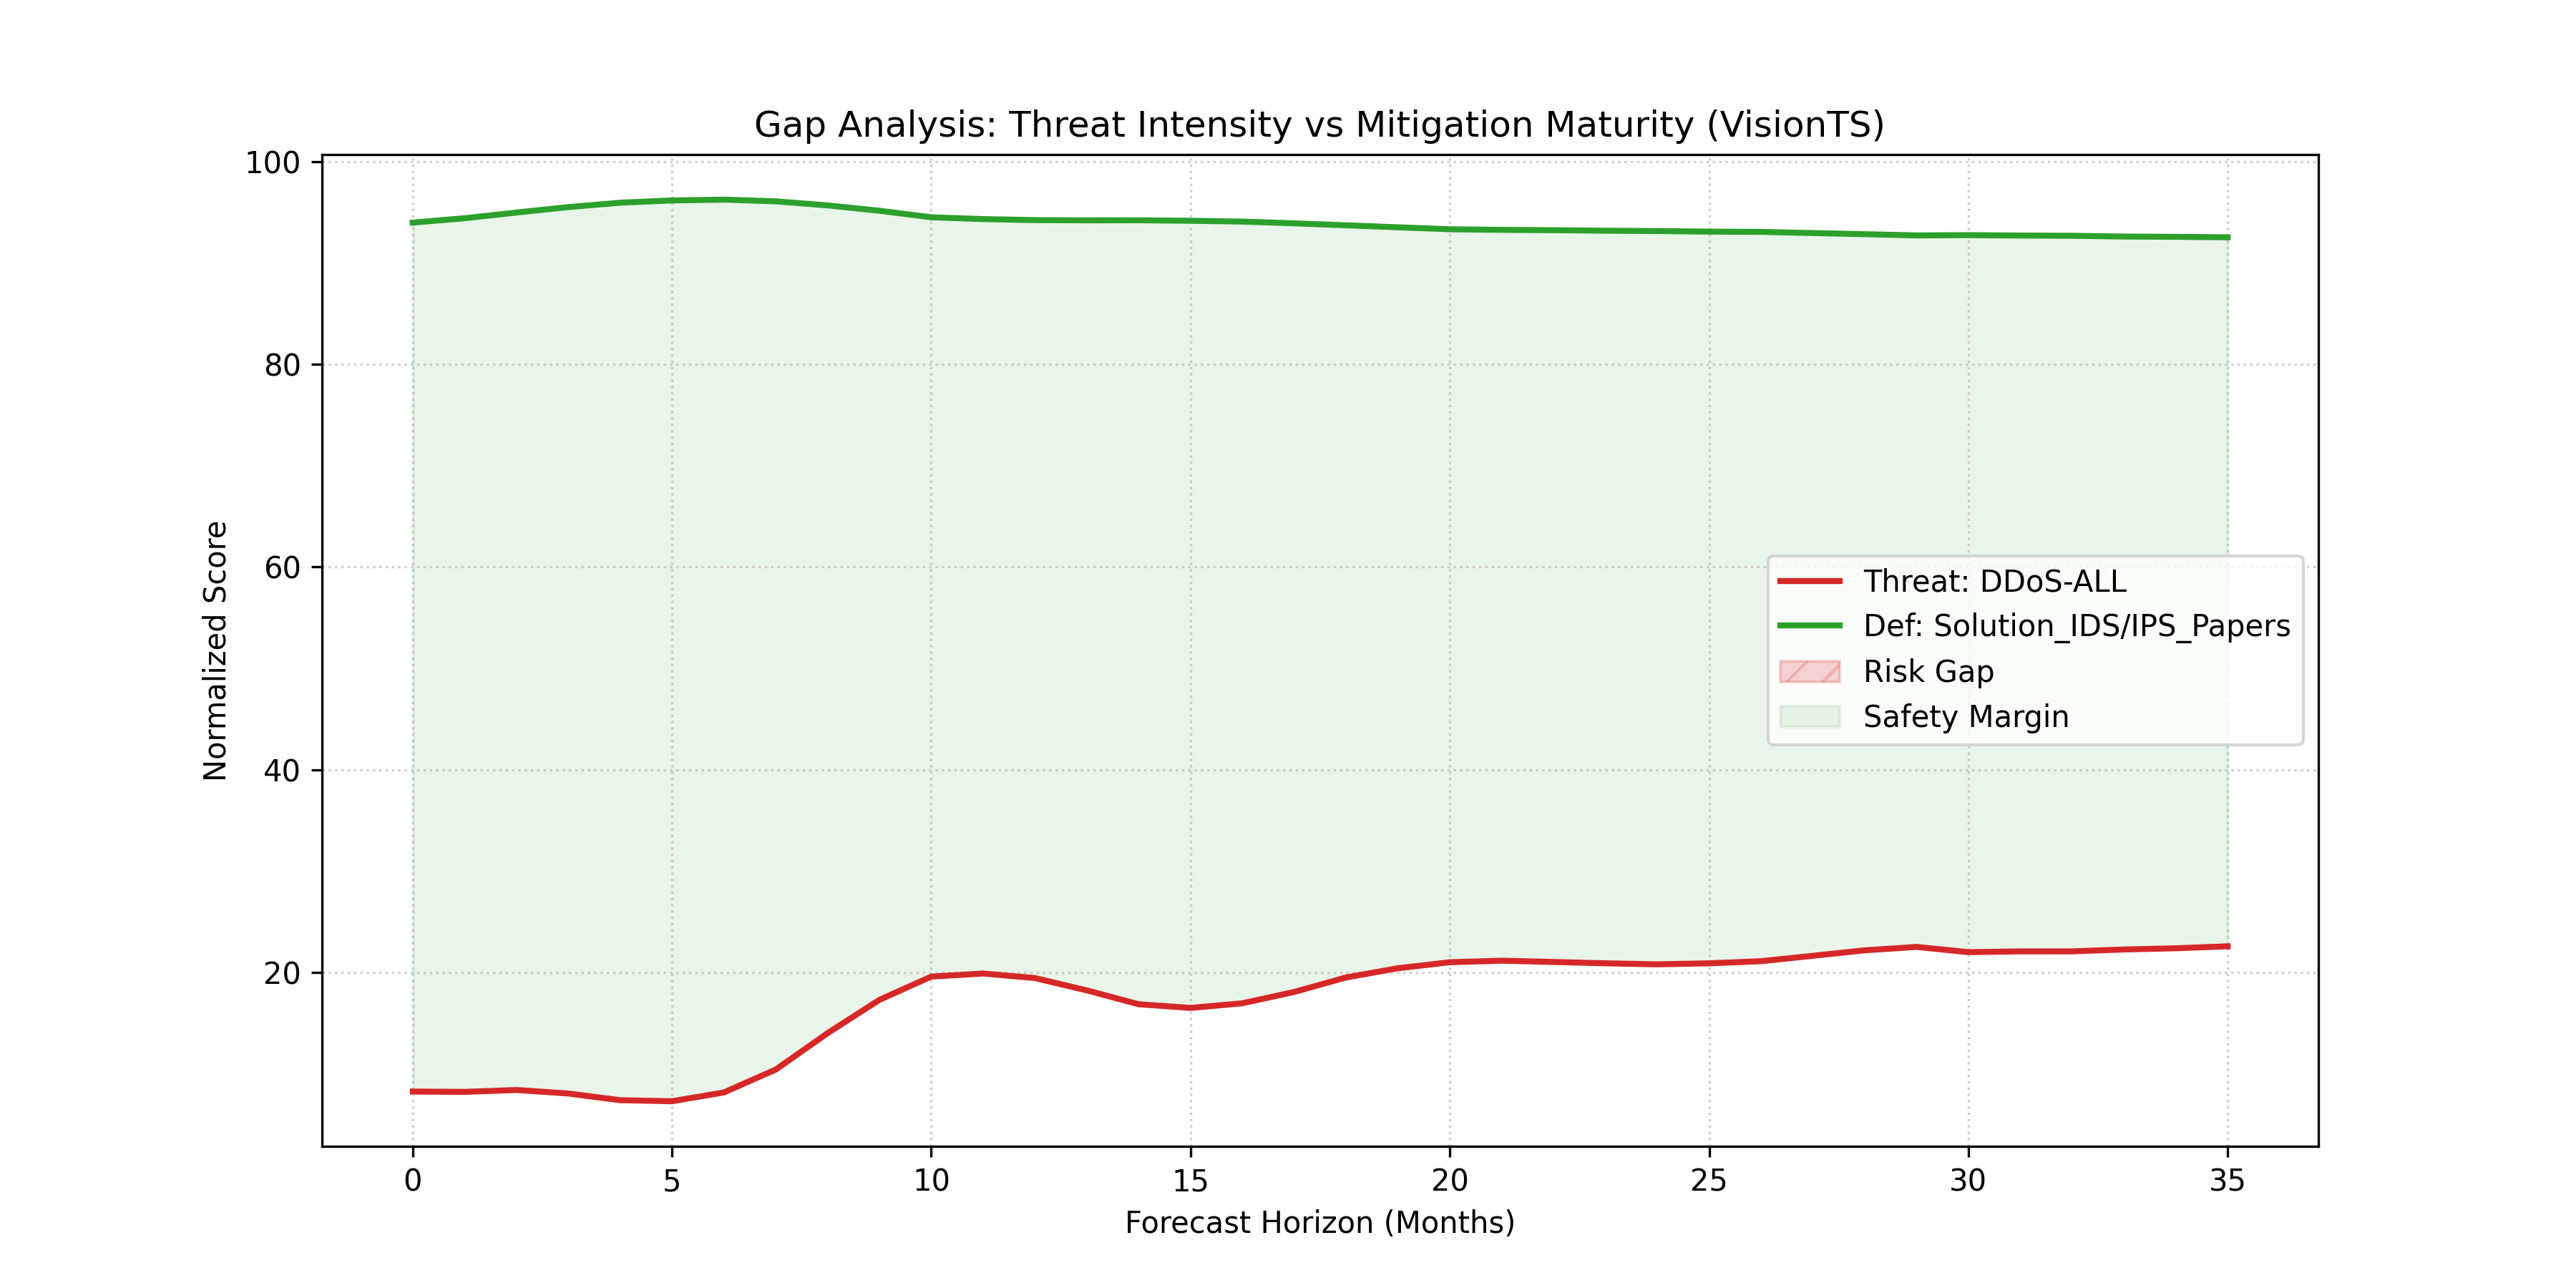


--- FORECAST ACCURACY: Ground Truth vs Prediction ---


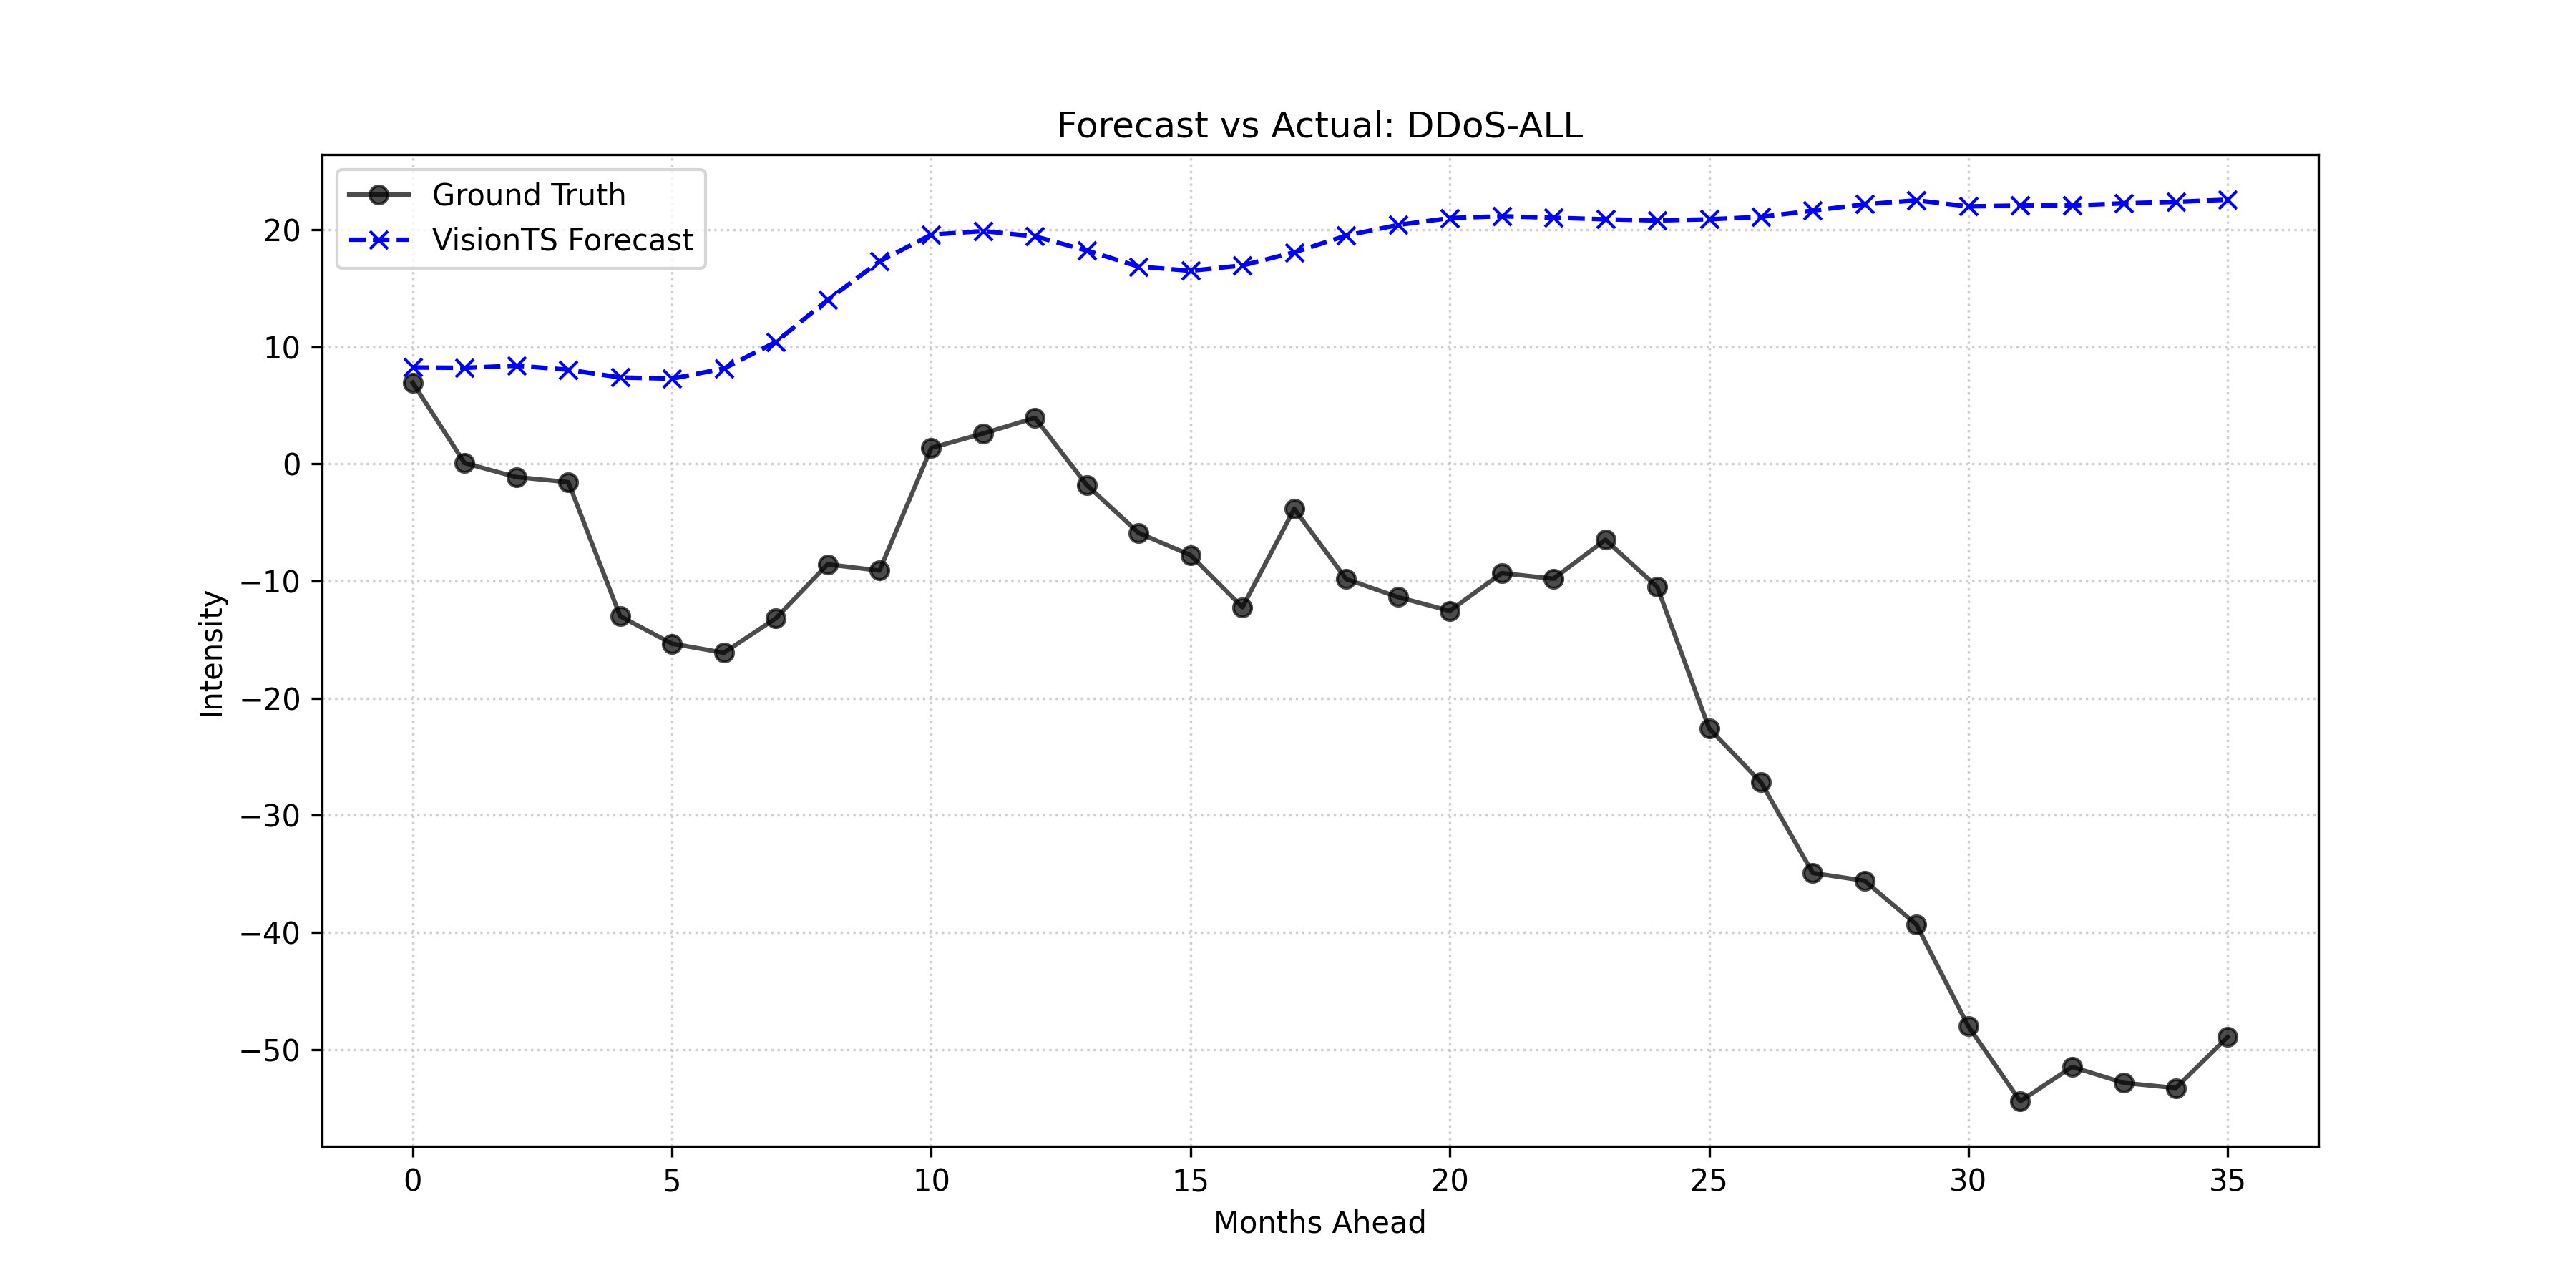

In [8]:
print("--- Step 3: Generating Visualisations ---")

# 1. Run the visualisation script to create PNGs
%run Visualise_Vision_Results.py

# 2. Display the images inline
import os
from IPython.display import Image, display

results_dir = 'Results'
gap_plot = os.path.join(results_dir, 'vision_gap_analysis.png')
forecast_plot = os.path.join(results_dir, 'vision_forecast_vs_actual.png')

print("\n--- GAP ANALYSIS: Threat vs Mitigation ---")
if os.path.exists(gap_plot):
    display(Image(filename=gap_plot))
else:
    print("Gap analysis plot not found.")

print("\n--- FORECAST ACCURACY: Ground Truth vs Prediction ---")
if os.path.exists(forecast_plot):
    display(Image(filename=forecast_plot))
else:
    print("Forecast plot not found.")